In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [26]:
df = pd.read_csv('../dataset_big/mnist/mnist_train.csv')
x_train = df.drop('label', axis=1)
y_train = df['label']

x_train.head(2)

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
x_train.shape

(60000, 784)

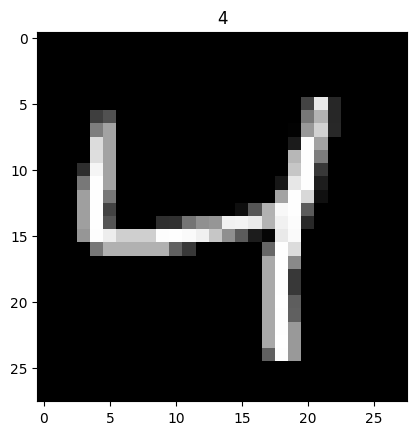

In [28]:
plt.imshow(x_train.values[2].reshape(28,28), cmap='gray')
plt.title(y_train.values[2])
plt.show()

In [29]:
x_train = x_train.astype("float32") / 255

In [36]:
pca = PCA(n_components=2)
T = pca.fit_transform(x_train)

In [37]:
reconstructed_data = pca.inverse_transform(T)

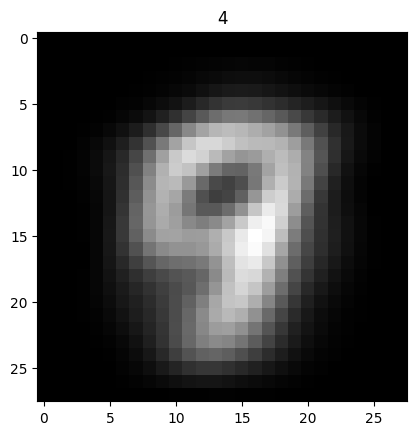

In [38]:

plt.imshow(reconstructed_data[2].reshape(28,28), cmap='gray')
plt.title(y_train.values[2])
plt.show()

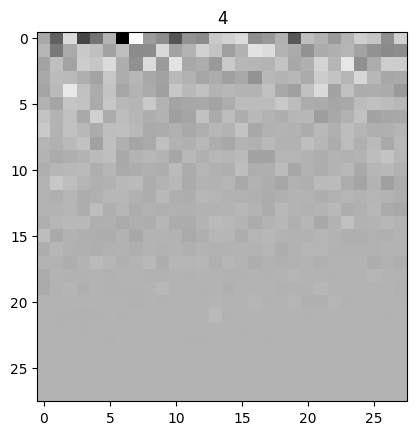

In [13]:
plt.imshow(T[2].reshape(28,28), cmap='gray')
plt.title(y_train.values[2])
plt.show()

In [12]:
print(pca.explained_variance_ratio_)

[9.70466435e-02 7.09592476e-02 6.16908930e-02 5.38941883e-02
 4.86879498e-02 4.31223176e-02 3.27192917e-02 2.88389549e-02
 2.76202913e-02 2.35700067e-02 2.10918952e-02 2.02299114e-02
 1.71581842e-02 1.69211160e-02 1.57864150e-02 1.48295257e-02
 1.32456096e-02 1.27689736e-02 1.18726296e-02 1.15268379e-02
 1.06616626e-02 1.00671332e-02 9.53573268e-03 9.12543759e-03
 8.83404631e-03 8.39319173e-03 8.12578853e-03 7.86366034e-03
 7.44733121e-03 6.90859277e-03 6.58093765e-03 6.48147799e-03
 6.02614926e-03 5.86582255e-03 5.70021570e-03 5.43627702e-03
 5.05786436e-03 4.87858523e-03 4.81429277e-03 4.72266367e-03
 4.56747040e-03 4.44835890e-03 4.18501254e-03 3.98215326e-03
 3.84974643e-03 3.75103462e-03 3.62008810e-03 3.51591245e-03
 3.40058096e-03 3.21874348e-03 3.19017028e-03 3.12804966e-03
 2.95982650e-03 2.88954517e-03 2.84130429e-03 2.71435827e-03
 2.69521400e-03 2.58472562e-03 2.53770500e-03 2.44780979e-03
 2.40506092e-03 2.39262939e-03 2.30408460e-03 2.21532118e-03
 2.13720836e-03 2.072250

In [14]:
pca = PCA(n_components=2)
T = pca.fit_transform(x_train)
T.shape

(60000, 2)

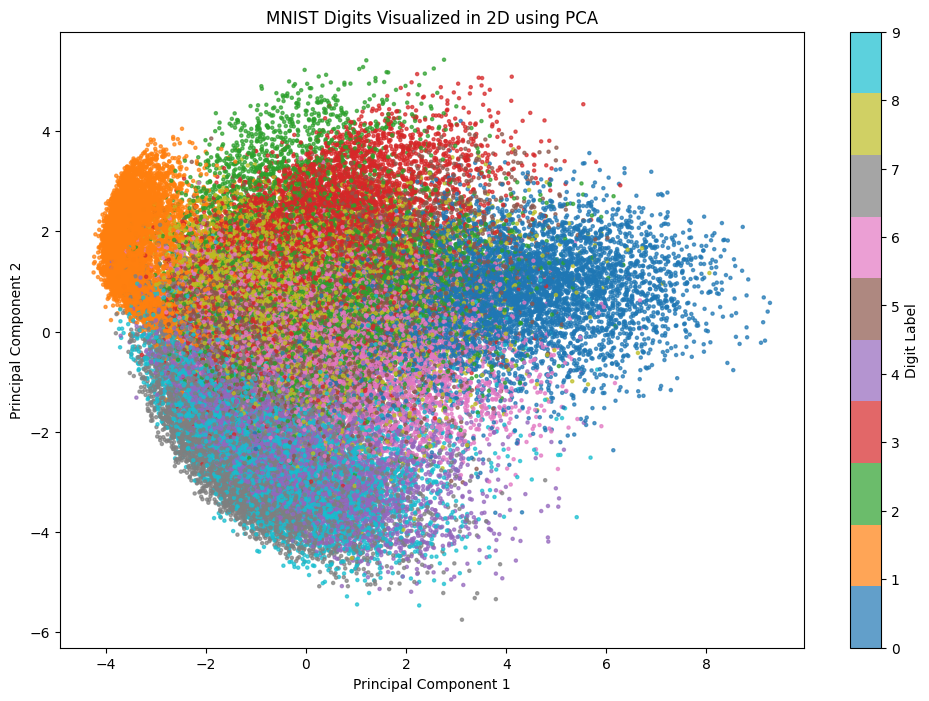

In [9]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='tab10', alpha=0.7, s=5)
plt.colorbar(scatter, label='Digit Label')
plt.title('MNIST Digits Visualized in 2D using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

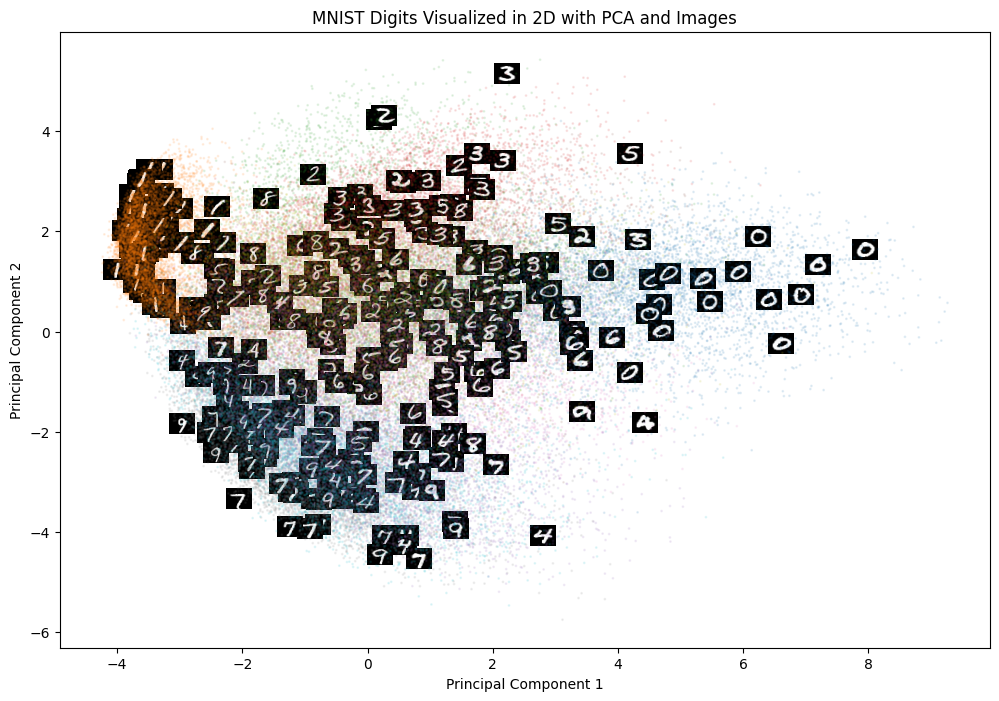

In [10]:

# Plot setup
plt.figure(figsize=(12, 8))
plt.title('MNIST Digits Visualized in 2D with PCA and Images')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot subset with digit images
indices = np.random.choice(len(T), size=300, replace=False)
for i in indices:
    x, y_pos = T[int(i),:]
    digit_image = x_train.values[i].reshape(28, 28)
    plt.imshow(
        digit_image, extent=(x-0.2, x+0.2, y_pos-0.2, y_pos+0.2), cmap='gray', aspect='auto'
    )

# Scatter plot for context
plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='tab10', alpha=0.1, s=1)

plt.show()


In [41]:
pca = PCA(n_components=2)
T = pca.fit_transform(x_train)
T.shape

(60000, 2)

In [42]:
# trasforma T in una DataFrame per visualizzare meglio i risultati
df_pca = pd.DataFrame(T, columns=[f'PC{i+1}' for i in range(T.shape[1])])
df_pca.head(2)

,PC1,PC2
0,0.486010,1.226173
1,3.967524,1.156302


In [43]:
y_train.head(2)

0    5
1    0
Name: label, dtype: int64

In [48]:
# voglio fare un classificatore logistico sulle prime 10 componenti principali
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(df_pca, y_train)
y_pred = clf.predict(df_pca)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_train, y_pred)
print(f'Accuracy on training set: {accuracy:.4f}')

Accuracy on training set: 0.4431


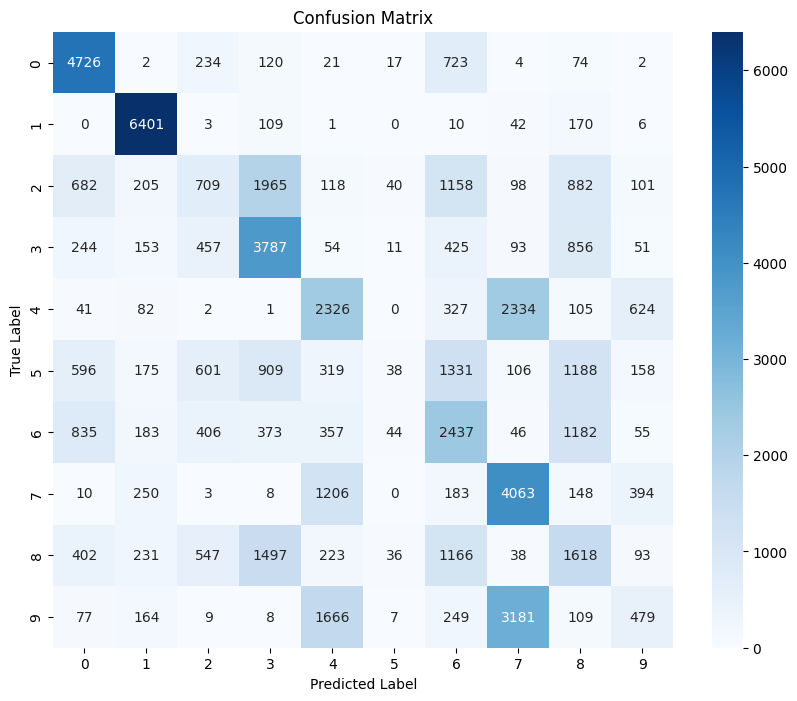

In [49]:
# confusion matix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train, y_pred)
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()  

In [50]:
y_pred[2]

np.int64(4)